In [54]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.datasets import load_iris

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys

# =====================================


In [2]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

<Axes: >

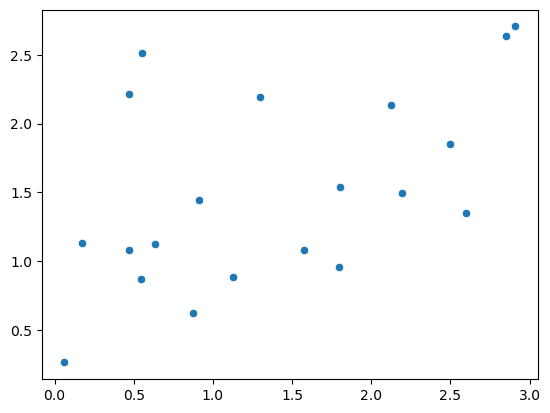

In [4]:
sns.scatterplot(x = np.ravel(X), y = np.ravel(y))

### Ridge regression for multiple value of alpha

In [33]:
alphas=(0, 10, 100)
getParams = []
X_new = np.linspace(0, 3, 100).reshape(100, 1)
for i in alphas:
    if i > 0:
        ridge_reg = Ridge(alpha=i,random_state=42, solver="cholesky")
        rgd = ridge_reg.fit(X, y)
        getParams.append([rgd.intercept_,rgd.coef_])
    else:
        linear = LinearRegression().fit(X,y)
        getParams.append([linear.intercept_,linear.coef_])

    

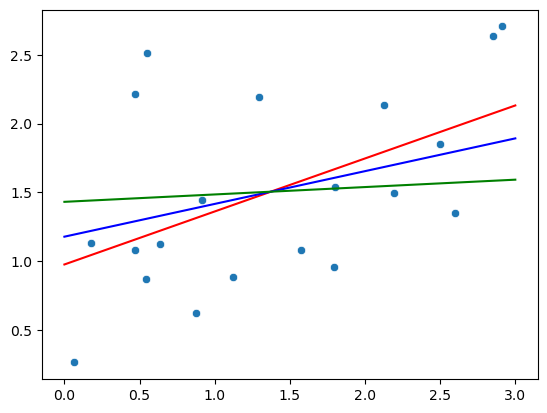

In [47]:
sns.scatterplot(x = np.ravel(X), y = np.ravel(y))
colour = ['r','b','g']
for i,j in zip(getParams,range(len(getParams))):
    val = getParams[j]
    Y_new = val[0] + val[1] * X_new
    sns.lineplot(x=np.ravel(X_new),y=np.ravel(Y_new),c = colour[j])

### Polynomial Regression with Ridge regularization

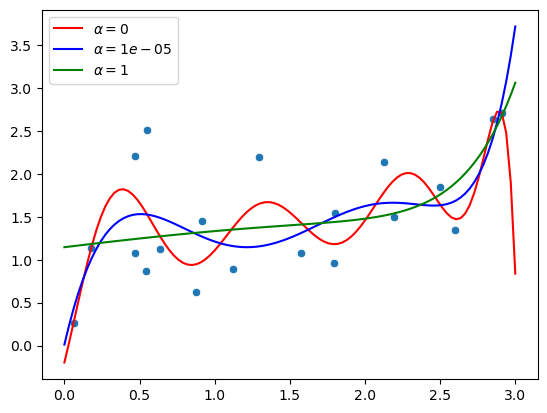

In [48]:
get_modol_param = []
j = 0
alphas = [0, 10**-5,1]
sns.scatterplot(x = np.ravel(X), y = np.ravel(y))
for i in alphas:
    if i > 0:
        ridge_reg = Ridge(alpha=i,random_state=42, solver="cholesky")
        model = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                ridge_reg)        
    else:
        linear = LinearRegression()
        model  = make_pipeline(
                PolynomialFeatures(degree=10, include_bias=False),
                StandardScaler(),
                linear)
    res = model.fit(X, y)
    Y_new = res.predict(X_new)
    sns.lineplot(x=np.ravel(X_new),y=np.ravel(Y_new),c=colour[j],label=fr"$\alpha = {i}$")
    j += 1
    

### Ridge regressions by using Stochastic Gradient Descent

In [ ]:
sgd_reg = SGDRegressor(penalty="l2")
sgd_reg.fit(X, y.ravel())

### Lasso
Just like Ridge Regression, it adds a regularization term to the cost function, but it uses the ℓ1 norm of the weight vector instead of half the square of the ℓ2 norm

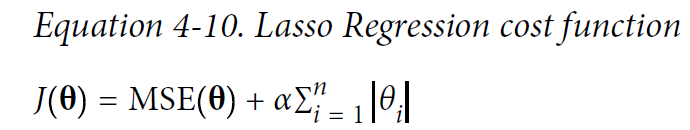

In [51]:
lasso_reg = Lasso(alpha=0.1)
lso = lasso_reg.fit(X, y)
lso.intercept_,lso.coef_

(array([1.14537356]), array([0.26167212]))

### Plot Lasso 
##### For different value of alpha
##### Polynomials regressions with Lasso regularizations for different value of alpha

### Lasso regressions by using Stochastic Gradient Descent

In [52]:
lasso_reg = Lasso(alpha=0.1)
lso = lasso_reg.fit(X, y)
lso.intercept_,lso.coef_

(array([1.14537356]), array([0.26167212]))

### Elastic Net

1. simple mix of both Ridge and Lasso’s regularization terms
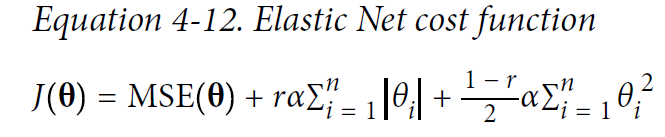

2. mix ratio r
    
r = 0, Elastic Net is equivalent to Ridge Regression.

r = 1, it is equivalent to Lasso Regression




In [55]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elst = elastic_net.fit(X, y)
elst.intercept_,elst.coef_

(array([1.08639303]), array([0.30462619]))

### when should you use plain Linear Regression (i.e., without any regularization) Ridge, Lasso, or Elastic Net?

Thumb rule 1: It is almost always preferable to have at least a little bit of
regularization, so generally you should avoid plain Linear Regression.

Ridge --> Use if multicolinearity exixt
Lasso --> Use for feture selections
Elatice-net --> Not in use
if you suspect that only a few features are actually useful, you should prefer
Lasso or Elastic Net since they tend to reduce the useless features’ weights down to
zero